# Twitter Fake Account Detection

## Step 1: Import Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)

plt.style.use('seaborn-v0_8-darkgrid')
print('Libraries loaded successfully!')

Libraries loaded successfully!


## Step 2: Load the Engineered Dataset


In [33]:
df = pd.read_csv('twibot_full_features.csv')

# Drop 'verified' - identified as biased feature (only 1 bot was verified)
df = df.drop(columns=['verified'], errors='ignore')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: (11826, 29)
Columns: ['id', 'followers_count', 'friends_count', 'statuses_count', 'listed_count', 'favourites_count', 'tweet_count', 'account_age', 'has_profile_pic', 'has_extended_profile', 'geo_enabled', 'is_translation_enabled', 'has_description', 'description_length', 'has_location', 'screen_name_length', 'followers_friends_ratio', 'statuses_friends_ratio', 'listed_followers_ratio', 'favourites_statuses_ratio', 'reputation_score', 'engagement_ratio', 'listing_rate', 'excessive_following', 'few_followers', 'low_tweet_count', 'follower_tweet_ratio', 'friend_tweet_ratio', 'label']


,id,followers_count,friends_count,statuses_count,listed_count,favourites_count,tweet_count,account_age,has_profile_pic,has_extended_profile,...,favourites_statuses_ratio,reputation_score,engagement_ratio,listing_rate,excessive_following,few_followers,low_tweet_count,follower_tweet_ratio,friend_tweet_ratio,label
0,u17461978,15349596,692,9798,45568,142,200,13,1,0,...,0.014493,0.999955,0.014493,0.002969,0,0,0,1566.605021,0.070627,0
1,u1297437077403885568,0,44,0,0,7,0,1,1,1,...,0.000000,0.000000,0.000000,0.000000,0,1,1,0.000000,0.000000,1
2,u17685258,762839,475,5518,3201,953,200,13,1,0,...,0.172708,0.999378,0.172708,0.004196,0,0,0,138.245560,0.086082,0


## Step 3: Feature Overview (All 26 Features)

| # | Feature | Type | Why it matters |
|---|---------|------|----------------|
| 1 | `followers_count` | Raw | High followers = more human-like |
| 2 | `friends_count` | Raw | Bots follow thousands, gain few followers |
| 3 | `statuses_count` | Raw | Total tweets ever posted |
| 4 | `listed_count` | Raw | Real users get added to curated lists |
| 5 | `favourites_count` | Raw | Bots rarely 'like' content |
| 6 | `tweet_count` | Raw | # tweets in dataset (max 200) |
| 7 | `has_profile_pic` | Binary | Bots often use default avatar |
| 8 | `has_extended_profile` | Binary | Bots rarely fill out full profiles |
| 9 | `geo_enabled` | Binary | Real users often share location |
| 10 | `is_translation_enabled` | Binary | Profile completeness indicator |
| 11 | `has_description` | Binary | Bots leave bio empty |
| 12 | `description_length` | Raw | Longer bio = more human-like |
| 13 | `has_location` | Binary | Real users set their city |
| 14 | `followers_friends_ratio` | **Engineered** | HIGH = human, LOW = bot |
| 15 | `statuses_friends_ratio` | **Engineered** | Tweet activity vs following activity |
| 16 | `listed_followers_ratio` | **Engineered** | How curated/valuable the account is |
| 17 | `favourites_statuses_ratio` | **Engineered** | Interaction vs broadcasting ratio |
| 18 | `reputation_score` | **Engineered** | followers/(followers+friends) - key metric |
| 19 | `engagement_ratio` | **Engineered** | likes/tweets - bots rarely like |
| 20 | `listing_rate` | **Engineered** | listed/followers |
| 21 | `screen_name_length` | **Engineered** | Bots often have random long names |
| 22 | `excessive_following` | **Heuristic** | 1 if friends > 5000 (bot red flag) |
| 23 | `few_followers` | **Heuristic** | 1 if followers < 50 (bot red flag) |
| 24 | `low_tweet_count` | **Heuristic** | 1 if statuses < 10 (bot red flag) |
| 25 | `follower_tweet_ratio` | **Engineered** | followers / statuses |
| 26 | `friend_tweet_ratio` | **Engineered** | friends / statuses |
| 27 | `account_age` |**Raw**| Years since account creation |

> **Note:** `verified` was removed after bias analysis — only 1 bot out of 4,646 was verified,  
> so the model was exploiting that as a shortcut rather than learning real patterns.

## Step 4: Exploratory Data Analysis (EDA)

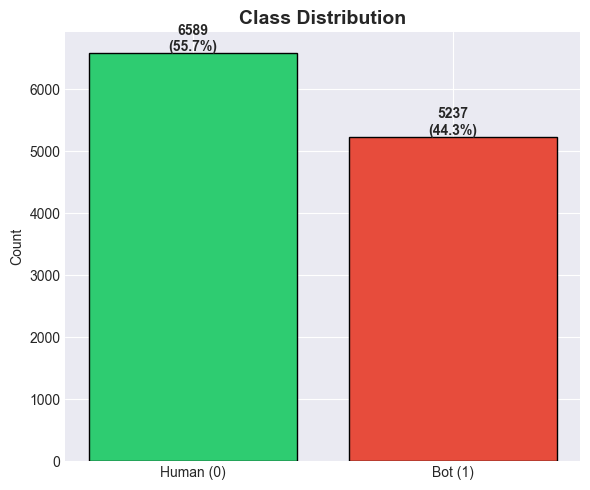

Class distribution plot saved!


In [41]:
# Class Distribution
fig, ax = plt.subplots(figsize=(6, 5))

# Plot only the Class distribution
counts = df['label'].value_counts()
ax.bar(['Human (0)', 'Bot (1)'], counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'eda_plots.png', dpi=120)
plt.show()
print('Class distribution plot saved!')


In [35]:
# Missing values & basic stats
print('Missing Values')
print(df.isnull().sum().sum(), 'total missing values')
print()
print('Basic Statistics')
df.groupby('label')[['reputation_score', 'followers_friends_ratio',
                      'engagement_ratio', 'few_followers']].mean().round(3)

Missing Values
0 total missing values

Basic Statistics


,reputation_score,followers_friends_ratio,engagement_ratio,few_followers
label,,,,
0,0.732,62722.982,18.757,0.098
1,0.438,648.477,7.788,0.168


## Step 5: Preprocessing & Train/Test Split

In [40]:
X = df.drop(['id', 'label'], axis=1)
y = df['label']
feature_names = X.columns.tolist()

print(f'Features used: {len(feature_names)}')
print(f'Feature names: {feature_names}')

# 80/20 split, stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain size: {len(X_train)} | Test size: {len(X_test)}')
print(f'Train bot%: {y_train.mean()*100:.1f}% | Test bot%: {y_test.mean()*100:.1f}%')

# Scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print('\nStandardScaler applied.')

Features used: 27
Feature names: ['followers_count', 'friends_count', 'statuses_count', 'listed_count', 'favourites_count', 'tweet_count', 'account_age', 'has_profile_pic', 'has_extended_profile', 'geo_enabled', 'is_translation_enabled', 'has_description', 'description_length', 'has_location', 'screen_name_length', 'followers_friends_ratio', 'statuses_friends_ratio', 'listed_followers_ratio', 'favourites_statuses_ratio', 'reputation_score', 'engagement_ratio', 'listing_rate', 'excessive_following', 'few_followers', 'low_tweet_count', 'follower_tweet_ratio', 'friend_tweet_ratio']

Train size: 9460 | Test size: 2366
Train bot%: 55.7% | Test bot%: 55.7%

StandardScaler applied.


## Step 6: Train & Compare Multiple Models

In [37]:
models = {
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=10, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'        : GaussianNB(),
}

results = {}
print(f'{"Model":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-'*70)

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    results[name] = {
        'model': model, 'y_pred': y_pred,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
    }
    r = results[name]
    print(f'{name:<25} {r["accuracy"]:>10.4f} {r["precision"]:>10.4f} {r["recall"]:>10.4f} {r["f1"]:>10.4f}')

best_name = max(results, key=lambda x: results[x]['f1'])
print(f'\nBEST MODEL: {best_name}  (F1={results[best_name]["f1"]:.4f})')

Model                       Accuracy  Precision     Recall         F1
----------------------------------------------------------------------
Random Forest                 0.7544     0.7331     0.8794     0.7996
Gradient Boosting             0.7591     0.7283     0.9052     0.8072
Logistic Regression           0.7418     0.7276     0.8574     0.7872
Decision Tree                 0.7227     0.7216     0.8179     0.7667
K-Nearest Neighbors           0.7101     0.7176     0.7906     0.7523
Naive Bayes                   0.6547     0.6190     0.9886     0.7613

BEST MODEL: Gradient Boosting  (F1=0.8072)


## Step 7: Confusion Matrix

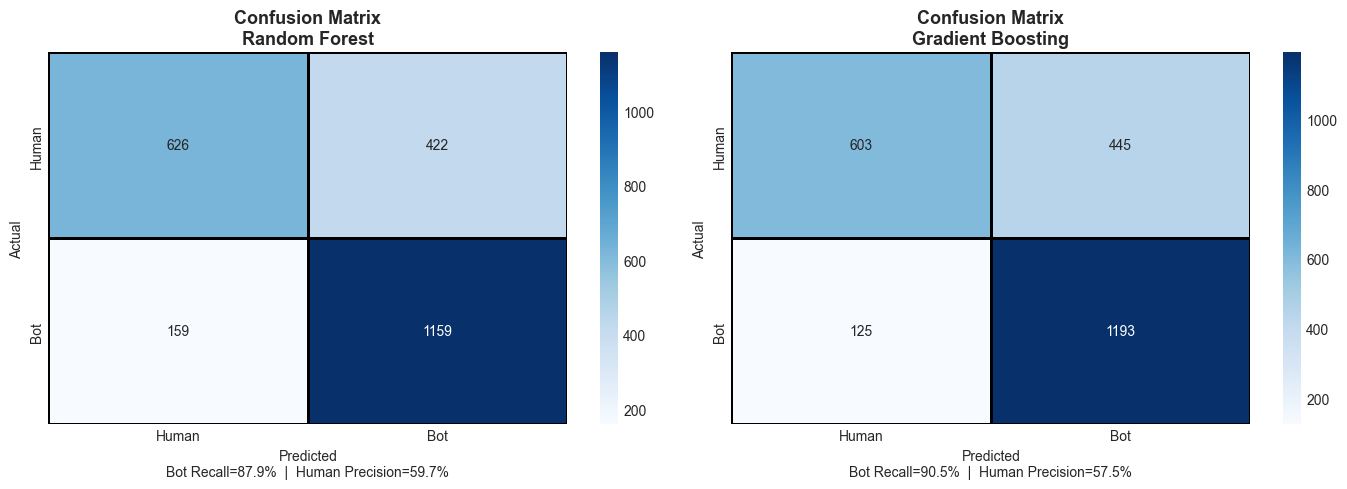

=== Classification Report (Gradient Boosting) ===
              precision    recall  f1-score   support

       Human       0.83      0.58      0.68      1048
         Bot       0.73      0.91      0.81      1318

    accuracy                           0.76      2366
   macro avg       0.78      0.74      0.74      2366
weighted avg       0.77      0.76      0.75      2366



In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Human', 'Bot'], yticklabels=['Human', 'Bot'],
                linewidths=1, linecolor='black')
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    TN, FP, FN, TP = cm.ravel()
    ax.set_xlabel(f'Predicted\nBot Recall={TP/(TP+FN)*100:.1f}%  |  Human Precision={TN/(TN+FP)*100:.1f}%')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

print('=== Classification Report (Gradient Boosting) ===')
print(classification_report(y_test, results['Gradient Boosting']['y_pred'],
                            target_names=['Human', 'Bot']))

## Step 8: Feature Importance

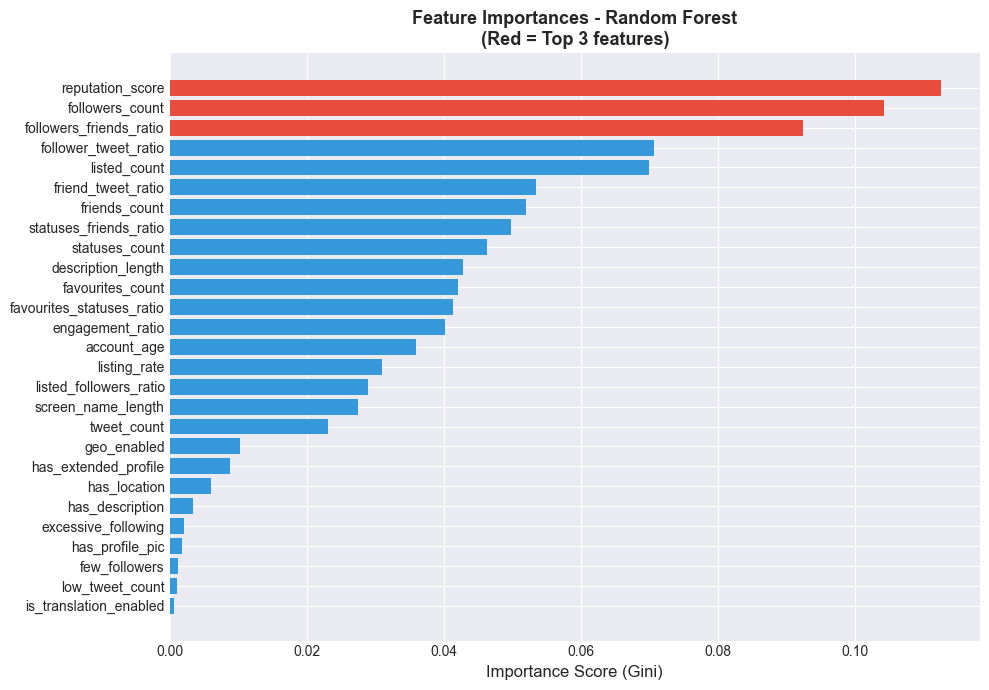

Top 10 Features:
                Feature  Importance
       reputation_score    0.112637
        followers_count    0.104287
followers_friends_ratio    0.092491
   follower_tweet_ratio    0.070760
           listed_count    0.069948
     friend_tweet_ratio    0.053420
          friends_count    0.052073
 statuses_friends_ratio    0.049846
         statuses_count    0.046303
     description_length    0.042774


In [39]:
rf = results['Random Forest']['model']
importances = rf.feature_importances_
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(imp_df))]
plt.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1], color=colors[::-1])
plt.xlabel('Importance Score (Gini)', fontsize=12)
plt.title('Feature Importances - Random Forest\n(Red = Top 3 features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()

print('Top 10 Features:')
print(imp_df.head(10).to_string(index=False))